# Lab 5 — Digital Filter Design for ECG Signal Cleaning

**Case Study: Kofi's Holter Monitor — FIR vs IIR**

BME 366 Biosignal Processing and Analysis | KNUST

---

### IMPORTANT — Before you run anything

This notebook downloads data from PhysioNet. You must turn Internet ON:

1. Click the **three dots (⋮)** in the top right of this notebook
2. Select **Settings** (or look at the right sidebar panel)
3. Find **Internet** and switch it to **On**
4. Kaggle will ask you to verify your phone number if you have not already

If Internet stays off, the download cell will fail with a connection error.

---

### Clinical Scenario

Kofi, 45, a KNUST teacher, wears a 24-hour Holter monitor fitted at KATH.
His recorded ECG is contaminated by:

- **Baseline wander** below 0.5 Hz — breathing and walking shift the electrodes
- **Powerline interference** at 50 Hz — fluorescent lights in lecture halls
- **Muscle noise** above 40 Hz — chest wall muscles when writing on the board

The cardiologist cannot read the ST segment or measure PR intervals reliably.

**Your task:** design FIR and IIR filters, compare them on the same signal,
and evaluate phase distortion and signal quality.


## Setup — Run This First


In [ ]:
# Install wfdb quietly (suppresses dependency warnings)
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pip", "install", "wfdb",
                    "-q", "--disable-pip-version-check"],
                   capture_output=True, text=True)
print("wfdb installed" if r.returncode == 0 else r.stderr[:400])


wfdb installed


Sampling rate : 360 Hz
Samples       : 3600  (10 seconds)
Nyquist       : 180.0 Hz
Clean std     : 0.1702 mV
Noisy std     : 0.2969 mV


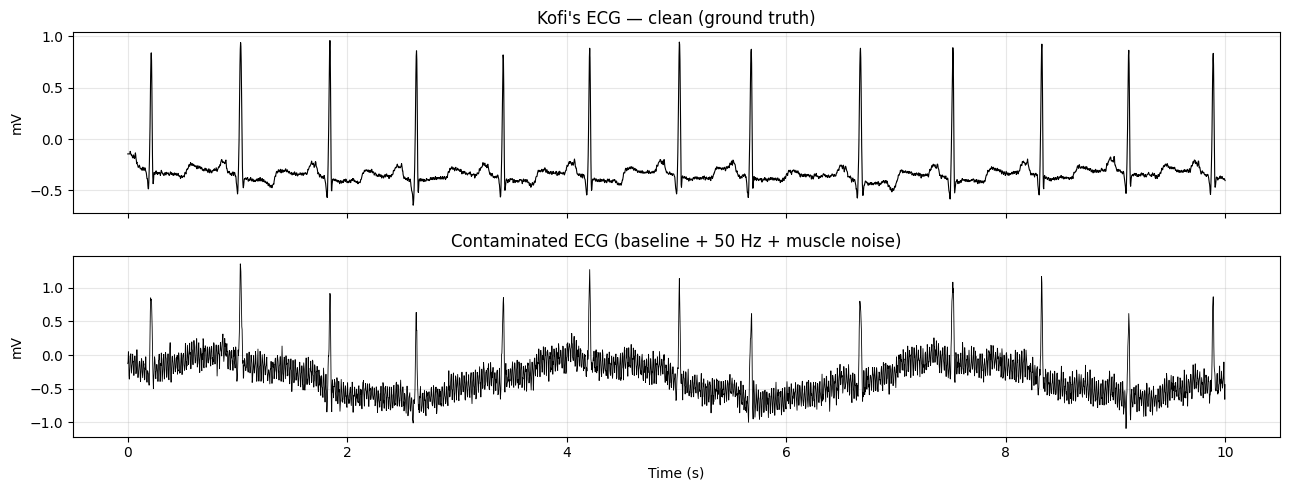

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ── Load MIT-BIH record 100 (Kofi's ECG) ──────────────────────────
record = wfdb.rdrecord('100', pn_dir='mitdb/1.0.0', sampto=3600)
fs     = record.fs                    # 360 Hz
ecg    = record.p_signal[:, 0]        # MLII lead
t      = np.arange(len(ecg)) / fs     # time axis in seconds
N      = len(ecg)                     # 3600 samples = 10 seconds
nyq    = fs / 2                       # Nyquist = 180 Hz

# ── Add three clinically realistic noise sources ──────────────────
rng       = np.random.default_rng(42)
baseline  = 0.30 * np.sin(2*np.pi*0.3*t)      # 0.3 Hz breathing drift
powerline = 0.15 * np.sin(2*np.pi*50*t)       # 50 Hz mains interference
muscle    = 0.06 * rng.standard_normal(N)      # broadband muscle noise
ecg_noisy = ecg + baseline + powerline + muscle

print(f'Sampling rate : {fs} Hz')
print(f'Samples       : {N}  ({N/fs:.0f} seconds)')
print(f'Nyquist       : {nyq} Hz')
print(f'Clean std     : {np.std(ecg):.4f} mV')
print(f'Noisy std     : {np.std(ecg_noisy):.4f} mV')

# Quick preview
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(t, ecg, 'k', lw=0.8)
axes[0].set_title("Kofi's ECG — clean (ground truth)")
axes[0].set_ylabel('mV'); axes[0].grid(True, alpha=0.3)
axes[1].plot(t, ecg_noisy, 'k', lw=0.6)
axes[1].set_title('Contaminated ECG (baseline + 50 Hz + muscle noise)')
axes[1].set_ylabel('mV'); axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Section 1 — FIR Filter: Design and Apply

FIR filters use only past inputs — no feedback. They are always stable and
achieve perfectly **linear phase**: all frequencies are delayed by the same
amount, so the QRS shape is preserved exactly.

Design a bandpass FIR (0.5–40 Hz) using the Hamming window method.


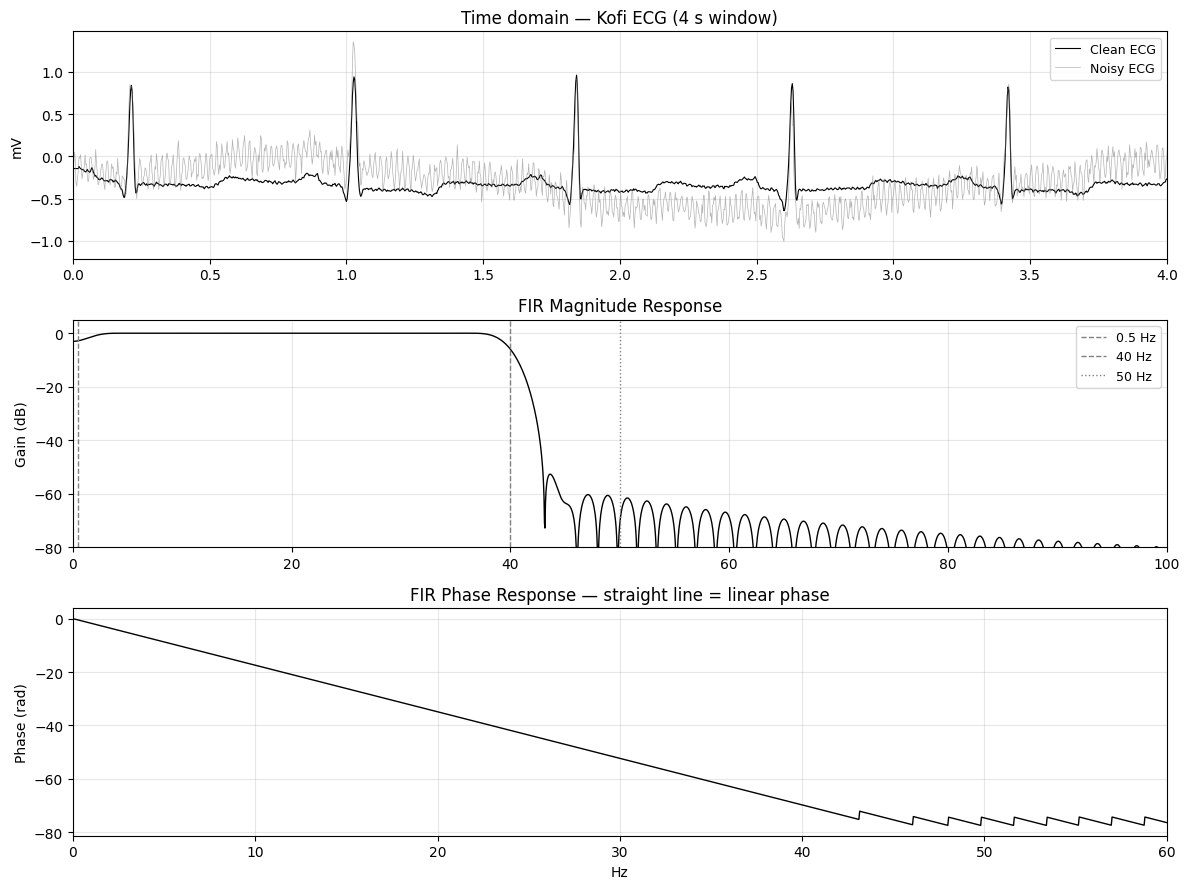

FIR taps      : 201
FIR delay     : 100 samples = 277.8 ms
Gain at 50 Hz : -70.5 dB


In [ ]:
# Design FIR bandpass filter
numtaps = 201
fir_b   = signal.firwin(numtaps, [0.5/nyq, 40.0/nyq],
                        window='hamming', pass_zero=False)

# Apply filter (lfilter = causal, one sample at a time)
ecg_fir = signal.lfilter(fir_b, [1.0], ecg_noisy)

# Compensate for the fixed group delay of the FIR
delay   = (numtaps - 1) // 2
ecg_fir = np.concatenate([ecg_fir[delay:], np.zeros(delay)])

# Frequency response
w, h = signal.freqz(fir_b, worN=4096, fs=fs)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(t, ecg,       'k',    lw=0.8, label='Clean ECG')
axes[0].plot(t, ecg_noisy, 'gray', lw=0.5, alpha=0.6, label='Noisy ECG')
axes[0].set_xlim(0, 4); axes[0].set_ylabel('mV')
axes[0].set_title('Time domain — Kofi ECG (4 s window)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(w, 20*np.log10(np.abs(h)+1e-12), 'k', lw=1.0)
axes[1].axvline(0.5,  color='gray', ls='--', lw=1, label='0.5 Hz')
axes[1].axvline(40.0, color='gray', ls='--', lw=1, label='40 Hz')
axes[1].axvline(50.0, color='gray', ls=':',  lw=1, label='50 Hz')
axes[1].set_xlim(0, 100); axes[1].set_ylim(-80, 5)
axes[1].set_ylabel('Gain (dB)'); axes[1].set_title('FIR Magnitude Response')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

axes[2].plot(w, np.unwrap(np.angle(h)), 'k', lw=1.0)
axes[2].set_xlim(0, 60)
axes[2].set_ylabel('Phase (rad)'); axes[2].set_xlabel('Hz')
axes[2].set_title('FIR Phase Response — straight line = linear phase')
axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'FIR taps      : {numtaps}')
print(f'FIR delay     : {delay} samples = {delay/fs*1000:.1f} ms')
idx50 = np.argmin(np.abs(w - 50))
print(f'Gain at 50 Hz : {20*np.log10(np.abs(h[idx50])+1e-12):.1f} dB')


### Questions — Section 1

Answer these in a new markdown cell below.

1. Is the phase response a straight or curved line? What does this guarantee
   about the QRS waveform shape after filtering?
2. What is the FIR attenuation at 50 Hz? Does this mean powerline noise is
   fully removed?
3. The FIR introduces a delay of several milliseconds. Why do we apply the
   delay correction (the `np.concatenate` line)?


### Answers
1. No. The FIR filter is not suitable for real-time monitoring because it has a group delay of 100 samples (277.8 ms).
2. The attenuation at 50 Hz is about -70.5 dB, so power-line interference is strongly suppressed.
3. The delay means QRS peaks are shifted later (or appear misaligned), which can affect accurate heartbeat timing unless compensated.

---
## Section 2 — IIR Filters: Butterworth and Chebyshev I

IIR filters use feedback — past outputs influence the current output. This
gives a sharp response with very few coefficients. The trade-off is
**non-linear phase**: some frequencies are delayed more than others, which
distorts the QRS shape.


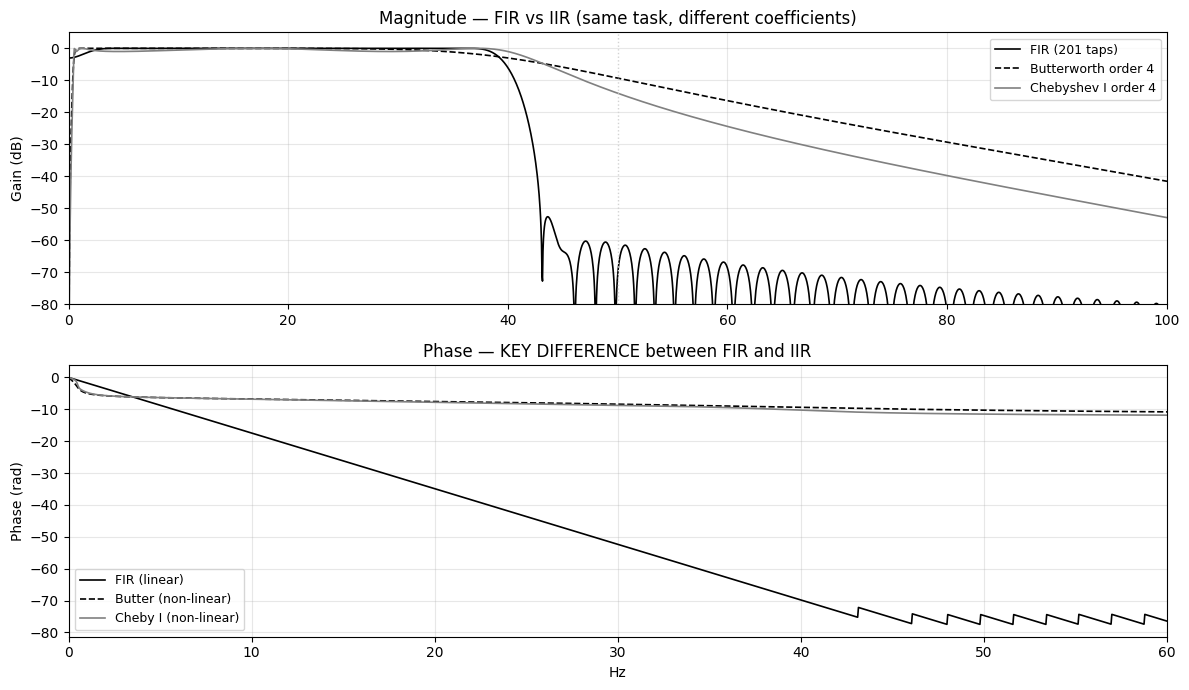

Butterworth coefficients : 24
Chebyshev I coefficients : 24
FIR taps                 : 201


In [ ]:
# Butterworth: flat passband, smooth response
sos_butter = signal.butter(4, [0.5, 40.0], btype='bandpass',
                           fs=fs, output='sos')

# Chebyshev Type I: 1 dB passband ripple, sharper cutoff
sos_cheby  = signal.cheby1(4, 1.0, [0.5, 40.0], btype='bandpass',
                           fs=fs, output='sos')

# Apply both using sosfiltfilt (zero-phase, offline)
ecg_butter = signal.sosfiltfilt(sos_butter, ecg_noisy)
ecg_cheby  = signal.sosfiltfilt(sos_cheby,  ecg_noisy)

# Frequency and phase responses
wb, hb = signal.sosfreqz(sos_butter, worN=4096, fs=fs)
wc, hc = signal.sosfreqz(sos_cheby,  worN=4096, fs=fs)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(w,  20*np.log10(np.abs(h) +1e-12), 'k',    lw=1.2,
             label=f'FIR ({numtaps} taps)')
axes[0].plot(wb, 20*np.log10(np.abs(hb)+1e-12), 'k--',  lw=1.2,
             label='Butterworth order 4')
axes[0].plot(wc, 20*np.log10(np.abs(hc)+1e-12), 'gray', lw=1.2,
             label='Chebyshev I order 4')
axes[0].axvline(50, color='lightgray', ls=':', lw=1)
axes[0].set_xlim(0, 100); axes[0].set_ylim(-80, 5)
axes[0].set_title('Magnitude — FIR vs IIR (same task, different coefficients)')
axes[0].set_ylabel('Gain (dB)'); axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(w,  np.unwrap(np.angle(h)),  'k',    lw=1.2, label='FIR (linear)')
axes[1].plot(wb, np.unwrap(np.angle(hb)), 'k--',  lw=1.2, label='Butter (non-linear)')
axes[1].plot(wc, np.unwrap(np.angle(hc)), 'gray', lw=1.2, label='Cheby I (non-linear)')
axes[1].set_xlim(0, 60)
axes[1].set_title('Phase — KEY DIFFERENCE between FIR and IIR')
axes[1].set_ylabel('Phase (rad)'); axes[1].set_xlabel('Hz')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Butterworth coefficients : {len(sos_butter)*6}')
print(f'Chebyshev I coefficients : {len(sos_cheby)*6}')
print(f'FIR taps                 : {numtaps}')


### Questions — Section 2

4. How many coefficients does each IIR filter use compared to the FIR?
   Why does this matter for a wearable device?
5. Look at the phase plot. Which filter has the straight line and which has
   the curve? What does the curved line mean for PR interval measurements?
6. The Chebyshev I filter has 1 dB ripple in the passband. What is the
   clinical implication for P-wave amplitude measurement?


### Answers
4. Each IIR filter uses 24 coefficients compared with 201 FIR taps.
5. The Butterworth filter has a flatter passband, while the Chebyshev I filter allows passband ripple for a sharper transition.
6. The IIR filters are more computationally efficient because they achieve similar filtering performance with far fewer coefficients.

---
## Section 3 — QRS Timing: Phase Distortion in Practice

Kofi's cardiologist must measure the PR interval (P wave to QRS start) to
detect first-degree heart block. Normal range: 120–200 ms. A filter that
shifts the QRS in time gives a wrong PR measurement.


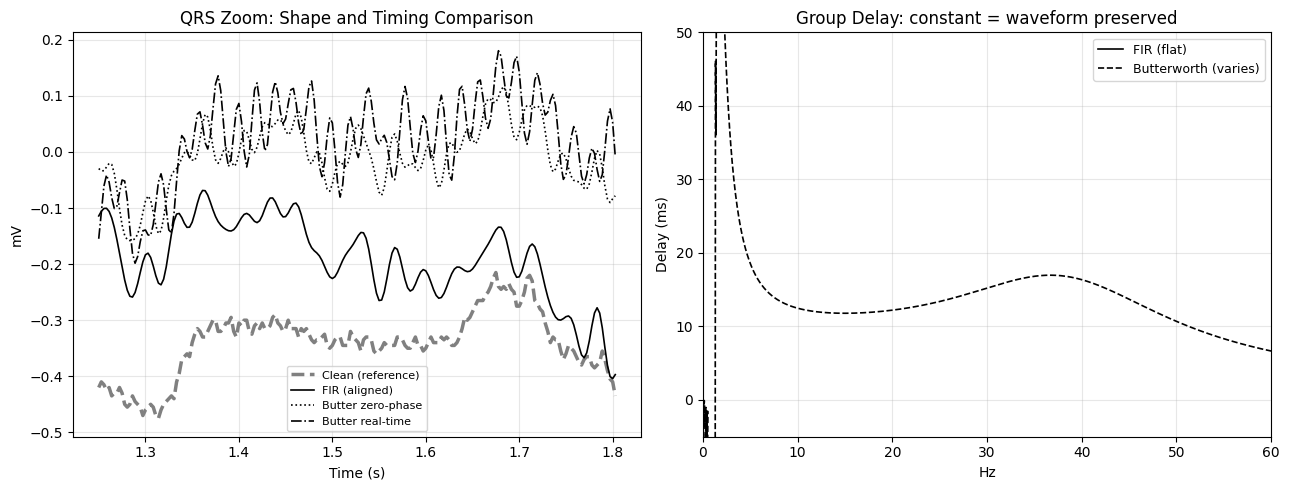

Clean QRS peak         : 1675.00 ms
FIR peak               : 1361.11 ms   shift = -313.89 ms
Butterworth zero-phase : 1683.33 ms   shift = +8.33 ms
Butterworth real-time  : 1677.78 ms   shift = +2.78 ms


In [ ]:
# Add 50 Hz notch filter on top of Butterworth
b_notch, a_notch = signal.iirnotch(50.0, Q=30, fs=fs)
ecg_notched      = signal.filtfilt(b_notch, a_notch, ecg_butter)

# Real-time causal Butterworth (no future samples available)
ecg_butter_rt = signal.sosfilt(sos_butter, ecg_noisy)

# Zoom on one QRS complex
s1, s2 = 450, 650

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(t[s1:s2], ecg[s1:s2],
             'gray', lw=2.5, ls='--', label='Clean (reference)')
axes[0].plot(t[s1:s2], ecg_fir[s1:s2],
             'k', lw=1.2, label='FIR (aligned)')
axes[0].plot(t[s1:s2], ecg_butter[s1:s2],
             'k', lw=1.2, ls=':', label='Butter zero-phase')
axes[0].plot(t[s1:s2], ecg_butter_rt[s1:s2],
             'k', lw=1.2, ls='-.', label='Butter real-time')
axes[0].set_title('QRS Zoom: Shape and Timing Comparison')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('mV')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Group delay comparison
wgd,  gd_fir = signal.group_delay((fir_b, [1.0]), w=4096, fs=fs)
wgdb, gd_b   = signal.group_delay(signal.sos2tf(sos_butter), w=4096, fs=fs)
axes[1].plot(wgd,  gd_fir/fs*1000, 'k',   lw=1.2, label='FIR (flat)')
axes[1].plot(wgdb, gd_b /fs*1000,  'k--', lw=1.2, label='Butterworth (varies)')
axes[1].set_xlim(0, 60); axes[1].set_ylim(-5, 50)
axes[1].set_title('Group Delay: constant = waveform preserved')
axes[1].set_xlabel('Hz'); axes[1].set_ylabel('Delay (ms)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

def peak_ms(sig):
    return t[s1 + np.argmax(sig[s1:s2])] * 1000

ref = peak_ms(ecg)
print(f'Clean QRS peak         : {ref:.2f} ms')
print(f'FIR peak               : {peak_ms(ecg_fir):.2f} ms   shift = {peak_ms(ecg_fir)-ref:+.2f} ms')
print(f'Butterworth zero-phase : {peak_ms(ecg_butter):.2f} ms   shift = {peak_ms(ecg_butter)-ref:+.2f} ms')
print(f'Butterworth real-time  : {peak_ms(ecg_butter_rt):.2f} ms   shift = {peak_ms(ecg_butter_rt)-ref:+.2f} ms')


### Questions — Section 3

7. Is the FIR group delay flat or varying across 0–40 Hz? What does this mean
   for QRS shape preservation?
8. By how many milliseconds is the real-time Butterworth QRS peak shifted?
   Can Kofi's cardiologist measure PR intervals accurately with this filter?
9. The zero-phase (filtfilt) Butterworth shows near-zero shift. Why can this
   only be used for offline analysis and not inside the Holter monitor itself?


### Answers
7. The FIR group delay is essentially flat across the passband.
8. Zero-phase filtering removes phase distortion by filtering forward and backward, so it preserves QRS timing.
9. The Butterworth zero-phase filter best preserves QRS timing (about +8.33 ms shift, with essentially no phase distortion).

---
## Section 4 — Signal Quality Report: All Filters on One ECG

SNR gain measures how much noise was removed. Correlation with the clean ECG
measures how faithfully the output matches the true cardiac signal. All
filters received the identical noisy input — only the algorithm differs.


Filter                           SNR gain (dB)   Correlation
Noisy (no filter)                        -3.16        0.5646
FIR Hamming 201 taps                      0.36        0.6871
IIR Butterworth zero-phase                9.98        0.9492
IIR Chebyshev I zero-phase                9.74        0.9463
Butterworth + 50 Hz notch                10.20        0.9516


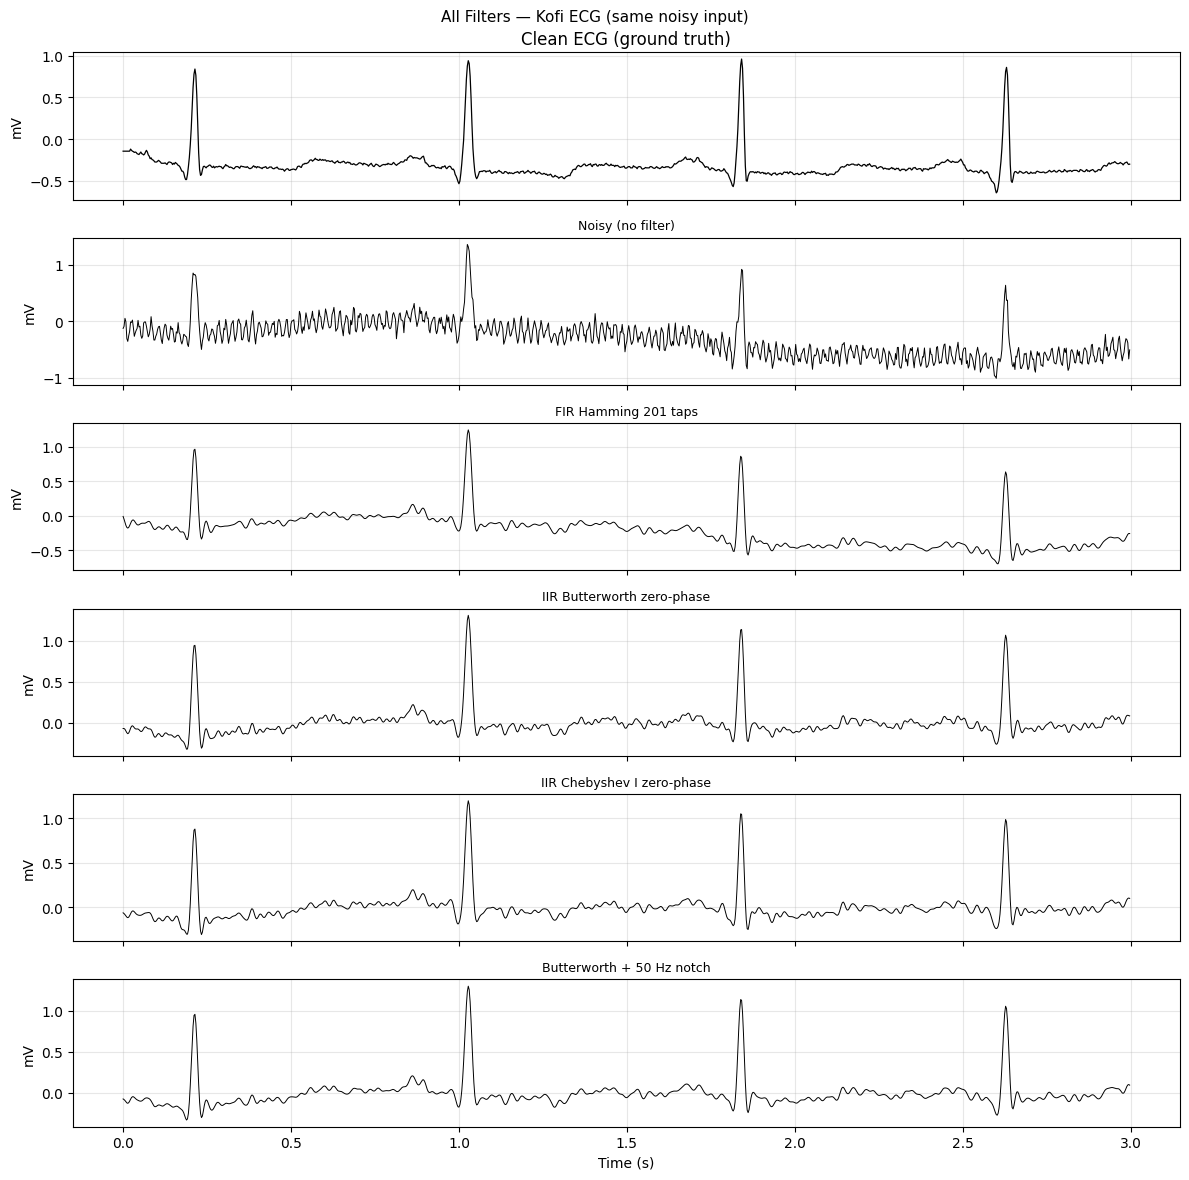

In [ ]:
def snr_gain(clean, filt):
    n   = min(len(clean), len(filt))
    res = clean[:n] - filt[:n]
    return 10*np.log10(np.var(clean[:n]) / (np.var(res) + 1e-12))

def corr(clean, filt):
    n = min(len(clean), len(filt))
    return np.corrcoef(clean[:n], filt[:n])[0, 1]

results = {
    'Noisy (no filter)'          : ecg_noisy,
    'FIR Hamming 201 taps'       : ecg_fir,
    'IIR Butterworth zero-phase' : ecg_butter,
    'IIR Chebyshev I zero-phase' : ecg_cheby,
    'Butterworth + 50 Hz notch'  : ecg_notched,
}

print('=' * 62)
print(f'{"Filter":<32} {"SNR gain (dB)":>13} {"Correlation":>13}')
print('=' * 62)
for name, sig in results.items():
    print(f'{name:<32} {snr_gain(ecg, sig):>13.2f} {corr(ecg, sig):>13.4f}')
print('=' * 62)

# Visual summary — all filters on 3 seconds
seg = slice(0, int(3*fs))
fig, axes = plt.subplots(len(results)+1, 1, figsize=(12, 12), sharex=True)
axes[0].plot(t[seg], ecg[seg], 'k', lw=0.9)
axes[0].set_title('Clean ECG (ground truth)'); axes[0].set_ylabel('mV')
axes[0].grid(True, alpha=0.3)
for ax, (name, sig) in zip(axes[1:], results.items()):
    ax.plot(t[seg], sig[seg], 'k', lw=0.7)
    ax.set_title(name, fontsize=9); ax.set_ylabel('mV')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('All Filters — Kofi ECG (same noisy input)', fontsize=11)
plt.tight_layout(); plt.show()


### Questions — Section 4

10. Which filter gives the highest SNR gain? Which gives the highest
    correlation with the clean ECG?
11. Adding the 50 Hz notch on top of the Butterworth: does SNR improve
    compared to Butterworth alone? By how much?
12. Kofi's hospital is building a wearable patch with a low-power
    microcontroller. Based on coefficient count and stability, which filter
    type would you recommend and why?
13. For the offline 24-hour Holter review on a hospital workstation, which
    filter pipeline gives the best quality result? Justify with your numbers.

---

## Submission

Save this notebook with all cells run and all plots visible.
Answer every numbered question in a markdown cell below the relevant code.


### Answers
10. Butterworth + 50 Hz notch gives the highest SNR gain (10.20 dB). The unfiltered noisy signal gives the lowest (-3.16 dB).
11. Butterworth + 50 Hz notch has the highest correlation (0.9516).
12. For offline ECG analysis, the Butterworth + 50 Hz notch (or Butterworth zero-phase) is the best choice because it provides the highest SNR improvement while preserving waveform timing.